# 프로처럼 해봅시다!

고급 RAG 기법(Advanced RAG Techniques)!

인제스트(ingest) 파이프라인부터 깊이 파고들겠습니다:

1. LangChain 없이! 최대 유연성을 위해 네이티브(native) 방식으로
2. LLM을 활용하여 문서를 의미 있는 방식으로 청크로 분할
3. 어제 검증한 최적의 청크 크기와 인코더 사용
4. LLM이 청크를 가장 유용한 형태로 재작성("문서 전처리")

> 💡 **전문가 조언**: 고급 RAG의 핵심은 **"검색 품질 향상"**입니다. LLM 기반 청크 분할, 리랭킹(re-ranking), 쿼리 재작성(query rewriting) 세 가지 기법을 조합하면 기본 RAG 대비 답변 품질을 크게 높일 수 있습니다.

In [1]:
# 필요한 라이브러리 임포트
# pydantic: LLM 응답을 구조화된 객체로 파싱 (Chunks, RankOrder 등)
# chromadb: LangChain 없이 직접 Chroma 클라이언트 사용
# tqdm: 진행 상황 시각화 (문서 수가 많을 때 유용)
# litellm: 여러 LLM 제공사를 통합 인터페이스로 호출 (OpenAI, Anthropic 등)
from pathlib import Path
from openai import OpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from chromadb import PersistentClient
from tqdm import tqdm
from litellm import completion
import numpy as np
from sklearn.manifold import TSNE
import plotly.graph_objects as go


load_dotenv(override=True)

MODEL = "gpt-4.1-nano"

# preprocessed_db: LLM으로 전처리된 청크를 저장할 새로운 벡터 저장소
DB_NAME = "preprocessed_db"
collection_name = "docs"
# 💡 text-embedding-3-large: OpenAI의 고성능 임베딩 모델 (day2의 HuggingFace 대비 더 높은 품질)
embedding_model = "text-embedding-3-large"
KNOWLEDGE_BASE_PATH = Path("knowledge-base")
AVERAGE_CHUNK_SIZE = 500

openai = OpenAI()

In [2]:
# LangChain의 Document 객체에서 영감을 받아 직접 구현한 유사 클래스
# page_content: 텍스트 내용 | metadata: 문서 출처 및 유형 정보
class Result(BaseModel):
    page_content: str
    metadata: dict

In [3]:
# 청크를 완벽하게 표현하는 클래스
# headline: 검색 쿼리에 잘 매칭될 간결한 제목
# summary: 자주 묻는 질문에 답할 수 있는 요약문 (검색 성능 향상)
# original_text: 원문 그대로 (변경 없음)
# 💡 headline + summary + original_text를 합쳐 저장하면 시맨틱 검색 정확도가 크게 향상됩니다
class Chunk(BaseModel):
    headline: str = Field(description="A brief heading for this chunk, typically a few words, that is most likely to be surfaced in a query")
    summary: str = Field(description="A few sentences summarizing the content of this chunk to answer common questions")
    original_text: str = Field(description="The original text of this chunk from the provided document, exactly as is, not changed in any way")

    def as_result(self, document):
        metadata = {"source": document["source"], "type": document["type"]}
        return Result(page_content=self.headline + "\n\n" + self.summary + "\n\n" + self.original_text,metadata=metadata)


class Chunks(BaseModel):
    chunks: list[Chunk]

## 세 단계:

1. LangChain처럼 지식 베이스에서 문서 가져오기
2. LLM을 호출하여 문서를 청크(Chunks)로 변환
3. 청크를 Chroma에 저장

끝!

### 1단계부터 시작합시다

In [4]:
def fetch_documents():
    """LangChain DirectoryLoader를 직접 구현한 버전"""
    # type: 폴더명(employees, products 등) | source: 파일 경로 | text: 문서 내용
    documents = []

    for folder in KNOWLEDGE_BASE_PATH.iterdir():
        doc_type = folder.name
        for file in folder.rglob("*.md"):
            with open(file, "r", encoding="utf-8") as f:
                documents.append({"type": doc_type, "source": file.as_posix(), "text": f.read()})

    print(f"Loaded {len(documents)} documents")
    return documents

In [5]:
documents = fetch_documents()

Loaded 76 documents


### 완료! 2단계로 - 청크 만들기

> 💡 **전문가 조언**: LLM 기반 청크 분할은 단순 문자 수 기반 분할보다 훨씬 스마트합니다. LLM이 문서의 의미적 구조를 이해하여 자연스러운 경계에서 분할하고, 각 청크에 헤드라인과 요약을 자동 생성합니다. 단, API 호출 비용이 증가하는 트레이드오프가 있습니다.

In [6]:
def make_prompt(document):
    # 문서 길이를 기반으로 적정 청크 수 추정 (AVERAGE_CHUNK_SIZE=500자 기준)
    how_many = (len(document["text"]) // AVERAGE_CHUNK_SIZE) + 1
    return f"""
You take a document and you split the document into overlapping chunks for a KnowledgeBase.

The document is from the shared drive of a company called Insurellm.
The document is of type: {document["type"]}
The document has been retrieved from: {document["source"]}

A chatbot will use these chunks to answer questions about the company.
You should divide up the document as you see fit, being sure that the entire document is returned in the chunks - don't leave anything out.
This document should probably be split into {how_many} chunks, but you can have more or less as appropriate.
There should be overlap between the chunks as appropriate; typically about 25% overlap or about 50 words, so you have the same text in multiple chunks for best retrieval results.

For each chunk, you should provide a headline, a summary, and the original text of the chunk.
Together your chunks should represent the entire document with overlap.

Here is the document:

{document["text"]}

Respond with the chunks.
"""

In [7]:
print(make_prompt(documents[0]))


You take a document and you split the document into overlapping chunks for a KnowledgeBase.

The document is from the shared drive of a company called Insurellm.
The document is of type: company
The document has been retrieved from: knowledge-base/company/about.md

A chatbot will use these chunks to answer questions about the company.
You should divide up the document as you see fit, being sure that the entire document is returned in the chunks - don't leave anything out.
This document should probably be split into 5 chunks, but you can have more or less as appropriate.
There should be overlap between the chunks as appropriate; typically about 25% overlap or about 50 words, so you have the same text in multiple chunks for best retrieval results.

For each chunk, you should provide a headline, a summary, and the original text of the chunk.
Together your chunks should represent the entire document with overlap.

Here is the document:

# About Insurellm

Insurellm was founded by Avery La

In [8]:
def make_messages(document):
    return [
        {"role": "user", "content": make_prompt(document)},
    ]

In [9]:
make_messages(documents[0])

[{'role': 'user',
  'content': "\nYou take a document and you split the document into overlapping chunks for a KnowledgeBase.\n\nThe document is from the shared drive of a company called Insurellm.\nThe document is of type: company\nThe document has been retrieved from: knowledge-base/company/about.md\n\nA chatbot will use these chunks to answer questions about the company.\nYou should divide up the document as you see fit, being sure that the entire document is returned in the chunks - don't leave anything out.\nThis document should probably be split into 5 chunks, but you can have more or less as appropriate.\nThere should be overlap between the chunks as appropriate; typically about 25% overlap or about 50 words, so you have the same text in multiple chunks for best retrieval results.\n\nFor each chunk, you should provide a headline, a summary, and the original text of the chunk.\nTogether your chunks should represent the entire document with overlap.\n\nHere is the document:\n\n# A

In [10]:
def process_document(document):
    # response_format=Chunks: LLM이 반드시 Chunks 스키마에 맞는 JSON을 반환하도록 강제
    # 💡 Pydantic 모델을 response_format으로 사용하면 구조화된 출력을 안정적으로 받을 수 있습니다
    messages = make_messages(document)
    response = completion(model=MODEL, messages=messages, response_format=Chunks)
    reply = response.choices[0].message.content
    doc_as_chunks = Chunks.model_validate_json(reply).chunks
    return [chunk.as_result(document) for chunk in doc_as_chunks]

In [11]:
process_document(documents[0])

[Result(page_content='Introduction and Founding of Insurellm\n\nInsurellm was founded in 2015 by Avery Lancaster as an insurance tech startup aiming to disrupt the industry with innovative products, starting with the marketplace Markellm.\n\nInsurellm was founded by Avery Lancaster in 2015 as an insurance tech startup designed to disrupt an industry in need of innovative products. Its first product was Markellm, the marketplace connecting consumers with insurance providers.', metadata={'source': 'knowledge-base/company/about.md', 'type': 'company'}),
 Result(page_content='Initial Growth and Product Expansion (2015-2020)\n\nThe company experienced rapid growth, expanding its product portfolio to include auto, home, and reinsurance platforms, reaching 200 employees across 12 U.S. offices by 2020.\n\nThe company experienced rapid growth in its first five years, expanding its product portfolio to include Carllm (auto insurance portal), Homellm (home insurance portal), and Rellm (enterprise

In [12]:
def create_chunks(documents):
    # tqdm: 진행 바 표시 (문서가 많을 때 처리 상황 파악)
    # 💡 문서 수가 많으면 속도가 느립니다. pro_implementation의 Python 모듈 버전은
    #    multiprocessing.Pool을 사용해 병렬 처리합니다 (Rate Limit 시 비활성화 가능)
    chunks = []
    for doc in tqdm(documents):
        chunks.extend(process_document(doc))
    return chunks

In [13]:
chunks = create_chunks(documents)

100%|██████████████████| 76/76 [08:07<00:00,  6.41s/it]


In [14]:
print(len(chunks))

381


### 생각보다 쉬웠죠! 다만 조금 느립니다.

파이썬 모듈 버전에서는 multiprocessing Pool을 사용해 병렬 실행하도록 구현했습니다.
Rate Limit 오류가 발생하면 코드에서 비활성화할 수 있습니다.

### 마지막으로, 3단계 - 임베딩 저장

In [15]:
def create_embeddings(chunks):
    # 기존 컬렉션이 있으면 삭제 후 재생성 (중복 방지)
    chroma = PersistentClient(path=DB_NAME)
    if collection_name in [c.name for c in chroma.list_collections()]:
        chroma.delete_collection(collection_name)

    # 모든 청크 텍스트를 한 번에 임베딩 (배치 처리로 효율적)
    texts = [chunk.page_content for chunk in chunks]
    emb = openai.embeddings.create(model=embedding_model, input=texts).data
    vectors = [e.embedding for e in emb]

    collection = chroma.get_or_create_collection(collection_name)

    # 각 청크에 고유 ID와 메타데이터를 붙여 Chroma에 저장
    ids = [str(i) for i in range(len(chunks))]
    metas = [chunk.metadata for chunk in chunks]

    collection.add(ids=ids, embeddings=vectors, documents=texts, metadatas=metas)
    print(f"Vectorstore created with {collection.count()} documents")

In [16]:
create_embeddings(chunks)

Vectorstore created with 381 documents


# 여기서 끝인가요... 맞죠?

잠깐! 제가 잊었을 거라고 생각했나요??

In [17]:
# day2와 동일하게 벡터 시각화를 위한 데이터를 준비합니다
# LLM 전처리 후 벡터가 어떻게 달라졌는지 day2 결과와 비교해보세요!
chroma = PersistentClient(path=DB_NAME)
collection = chroma.get_or_create_collection(collection_name)
result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
metadatas = result['metadatas']
doc_types = [metadata['type'] for metadata in metadatas]
colors = [['blue', 'green', 'red', 'orange'][['products', 'employees', 'contracts', 'company'].index(t)] for t in doc_types]

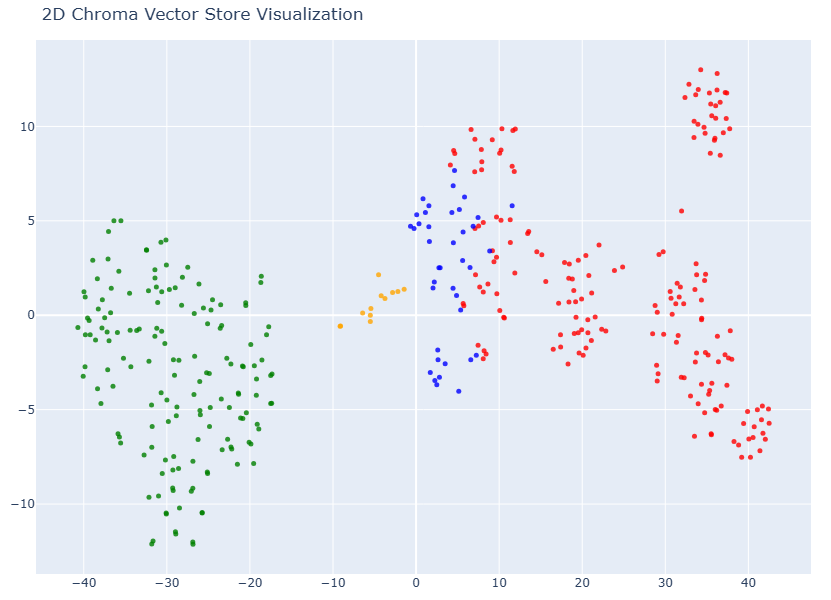

In [18]:
tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 2D scatter plot
fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(title='2D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x',yaxis_title='y'),
    width=800,
    height=600,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

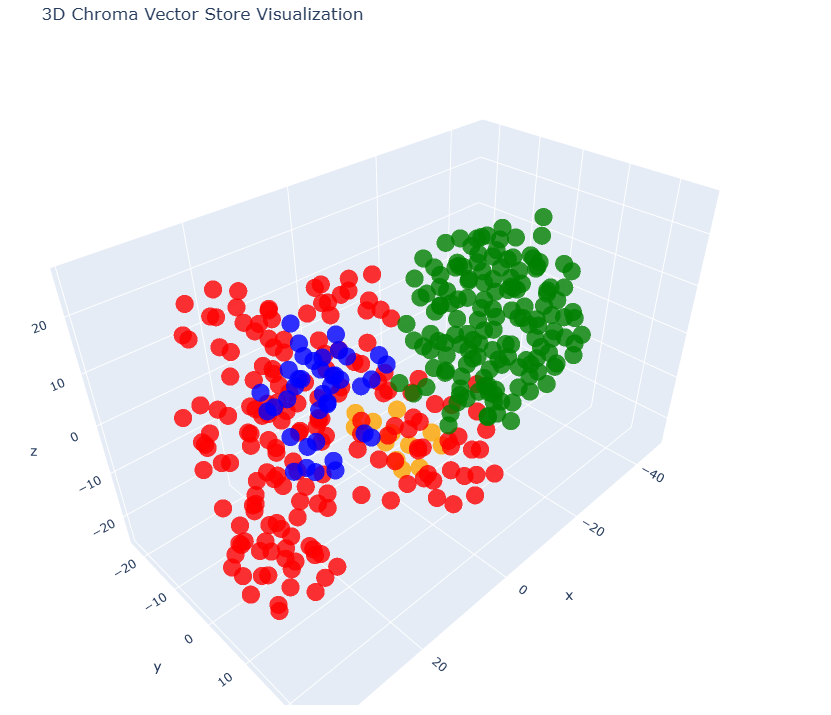

In [19]:
tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=900,
    height=700,
    margin=dict(r=10, b=10, l=10, t=40)
)

fig.show()

## 이제 고급 RAG를 구축합시다!

다음 기법들을 사용합니다:

1. **리랭킹(Reranking)** - 검색된 청크의 순위를 재조정
2. **쿼리 재작성(Query re-writing)** - 사용자 질문을 검색에 최적화된 형태로 변환

> 💡 **전문가 조언**: 리랭킹은 "2단계 검색"이라고도 불립니다. 1단계(벡터 검색)로 후보군을 넓게 가져온 후, 2단계(LLM 리랭킹)로 정밀도를 높입니다. 쿼리 재작성은 구어체/줄임말이 많은 실제 사용자 질문을 벡터 검색에 더 유리한 형태로 정제합니다.

In [20]:
# 리랭킹 결과를 담는 Pydantic 모델
# order: 청크 ID 번호를 관련성 높은 순서로 정렬한 리스트
# 💡 Pydantic + response_format 조합으로 LLM이 반드시 정수 리스트를 반환하도록 강제합니다
class RankOrder(BaseModel):
    order: list[int] = Field(
        description="The order of relevance of chunks, from most relevant to least relevant, by chunk id number"
    )

In [21]:
def rerank(question, chunks):
    # 시스템 프롬프트: LLM에게 리랭커 역할 부여
    # 벡터 유사도 순서를 LLM의 이해력으로 개선
    system_prompt = """
You are a document re-ranker.
You are provided with a question and a list of relevant chunks of text from a query of a knowledge base.
The chunks are provided in the order they were retrieved; this should be approximately ordered by relevance, but you may be able to improve on that.
You must rank order the provided chunks by relevance to the question, with the most relevant chunk first.
Reply only with the list of ranked chunk ids, nothing else. Include all the chunk ids you are provided with, reranked.
"""
    user_prompt = f"The user has asked the following question:\n\n{question}\n\nOrder all the chunks of text by relevance to the question, from most relevant to least relevant. Include all the chunk ids you are provided with, reranked.\n\n"
    user_prompt += "Here are the chunks:\n\n"
    for index, chunk in enumerate(chunks):
        user_prompt += f"# CHUNK ID: {index + 1}:\n\n{chunk.page_content}\n\n"
    user_prompt += "Reply only with the list of ranked chunk ids, nothing else."
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    response = completion(model=MODEL, messages=messages, response_format=RankOrder)
    reply = response.choices[0].message.content
    # RankOrder.order의 ID는 1-based이므로 i-1로 인덱싱
    order = RankOrder.model_validate_json(reply).order
    print(order)
    return [chunks[i - 1] for i in order]

In [22]:
# RETRIEVAL_K: 리랭킹 전 후보 청크 수
# 💡 리랭킹을 사용할 때는 K를 크게 설정(10~20)해 후보군을 넓히는 것이 효과적입니다
# 리랭킹 없이 쓸 때는 K=4~5 정도가 적당합니다
RETRIEVAL_K = 10

def fetch_context_unranked(question):
    # 질문을 임베딩으로 변환 후 벡터 유사도 검색 (Chroma 직접 호출)
    query = openai.embeddings.create(model=embedding_model, input=[question]).data[0].embedding
    results = collection.query(query_embeddings=[query], n_results=RETRIEVAL_K)
    chunks = []
    for result in zip(results["documents"][0], results["metadatas"][0]):
        chunks.append(Result(page_content=result[0], metadata=result[1]))
    return chunks

In [23]:
question = "Who won the IIOTY award?"
chunks = fetch_context_unranked(question)

In [24]:
for chunk in chunks:
    print(chunk.page_content[:15]+"...")

Insurellm Caree...
Annual Performa...
Additional HR N...
Performance Rev...
Career Progress...
Career Progress...
Annual Performa...
Annual Performa...
Annual Performa...
Compensation an...


In [25]:
reranked = rerank(question, chunks)

[1, 3, 2, 4, 5, 6, 7, 8, 9, 10]


In [26]:
for chunk in reranked:
    print(chunk.page_content[:15]+"...")

Insurellm Caree...
Additional HR N...
Annual Performa...
Performance Rev...
Career Progress...
Career Progress...
Annual Performa...
Annual Performa...
Annual Performa...
Compensation an...


In [27]:
# 리랭킹 효과를 확인하는 실험: Manchester 키워드가 몇 번째 청크에 있는지 확인
# RETRIEVAL_K를 20으로 늘려 더 넓은 후보군에서 리랭킹 효과를 측정
question = "Who went to Manchester University?"
RETRIEVAL_K = 20
chunks = fetch_context_unranked(question)
for index, c in enumerate(chunks):
    if "manchester" in c.page_content.lower():
        print(index)

In [28]:
reranked = rerank(question, chunks)

[15, 20, 13, 16, 6, 12, 17, 18, 1, 7, 3, 4, 5, 8, 9, 10, 11, 19, 2]


In [29]:
for index, c in enumerate(reranked):
    if "manchester" in c.page_content.lower():
        print(index)

In [30]:
reranked[0].page_content

'HR Record and Personal Details\n\nThis chunk introduces Samuel Trenton, including basic personal information and employment details at Insurellm.\n\n# HR Record\n\n# Samuel Trenton\n\n## Summary\n- **Date of Birth:** April 12, 1989\n- **Job Title:** Senior Data Scientist\n- **Location:** Austin, Texas\n- **Current Salary:** $115,000'

In [31]:
def fetch_context(question):
    chunks = fetch_context_unranked(question)
    return rerank(question, chunks)

In [32]:
# 고급 RAG용 시스템 프롬프트
# "정확도, 관련성, 완전성으로 평가된다"는 명시적 지시가 LLM의 답변 품질을 향상시킵니다
# 💡 프롬프트에 평가 기준을 직접 언급하면 LLM이 그 기준에 맞춰 더 신중하게 답변을 작성합니다
SYSTEM_PROMPT = """
You are a knowledgeable, friendly assistant representing the company Insurellm.
You are chatting with a user about Insurellm.
Your answer will be evaluated for accuracy, relevance and completeness, so make sure it only answers the question and fully answers it.
If you don't know the answer, say so.
For context, here are specific extracts from the Knowledge Base that might be directly relevant to the user's question:
{context}

With this context, please answer the user's question. Be accurate, relevant and complete.
"""

In [33]:
# 컨텍스트에 청크의 출처(source)를 포함합니다
# 💡 출처 정보를 포함하면 LLM이 답변의 근거를 밝힐 수 있어 신뢰성이 높아집니다
def make_rag_messages(question, history, chunks):
    context = "\n\n".join(f"Extract from {chunk.metadata['source']}:\n{chunk.page_content}" for chunk in chunks)
    system_prompt = SYSTEM_PROMPT.format(context=context)
    return [{"role": "system", "content": system_prompt}] + history + [{"role": "user", "content": question}]

In [34]:
def rewrite_query(question, history=[]):
    """사용자 질문을 지식 베이스 검색에 최적화된 형태로 재작성합니다.
    대화 기록을 고려하여 모호한 대명사나 지시어를 명확한 검색어로 변환합니다."""
    # 💡 쿼리 재작성의 핵심: "그 사람은 어디 출신이에요?" → "Avery Lancaster 출신 대학"
    # 대화 기록을 참조해 대명사를 실제 이름으로 바꿔주는 것이 핵심 역할입니다
    message = f"""
You are in a conversation with a user, answering questions about the company Insurellm.
You are about to look up information in a Knowledge Base to answer the user's question.

This is the history of your conversation so far with the user:
{history}

And this is the user's current question:
{question}

Respond only with a single, refined question that you will use to search the Knowledge Base.
It should be a VERY short specific question most likely to surface content. Focus on the question details.
Don't mention the company name unless it's a general question about the company.
IMPORTANT: Respond ONLY with the knowledgebase query, nothing else.
"""
    response = completion(model=MODEL, messages=[{"role": "system", "content": message}])
    return response.choices[0].message.content

In [35]:
rewrite_query("Who won the IIOTY award?", [])

'Who received the IIOTY award?'

In [36]:
def answer_question(question: str, history: list[dict] = []) -> tuple[str, list]:
    """
    RAG를 사용하여 질문에 답하고 답변과 검색된 컨텍스트를 반환합니다.
    전체 고급 RAG 파이프라인: 쿼리 재작성 → 벡터 검색 → 리랭킹 → LLM 답변 생성
    """
    # 1단계: 쿼리 재작성 (검색에 최적화된 형태로 변환)
    query = rewrite_query(question, history)
    print(query)
    # 2단계: 벡터 검색 + 리랭킹
    chunks = fetch_context(query)
    # 3단계: RAG 메시지 조립 후 LLM 호출
    messages = make_rag_messages(question, history, chunks)
    response = completion(model=MODEL, messages=messages)
    return response.choices[0].message.content, chunks

In [37]:
answer_question("Who won the IIOTY award?", [])

Who received the IIOTY award?
[1, 2, 12, 3, 4, 6, 8, 11, 13, 14, 16, 18, 19, 5, 7, 9, 10, 15, 17, 20]


('Maxine Thompson at Insurellm was recognized as the Insurellm IIOTY Innovator Award winner in 2023.',
 [Result(page_content="Additional HR Notes and Recognition\n\nThis chunk highlights Maxine Thompson's participation in company trainings, awards, leadership roles, and her involvement in initiatives promoting diversity and mentorship.\n\n## Other HR Notes\n- Maxine participated in various company-sponsored trainings related to big data technologies and cloud infrastructure.  \n- She was recognized for her contributions with the prestigious Insurellm IIOTY Innovator Award in 2023.  \n- Maxine is currently involved in the women-in-tech initiative and participates in mentorship programs to guide junior employees.  \n- Future development areas include improving her stakeholder communication skills to ensure smoother project transitions and collaboration.", metadata={'type': 'employees', 'source': 'knowledge-base/employees/Maxine Thompson.md'}),
  Result(page_content="Insurellm Career Prog

In [38]:
answer_question("Who went to Manchester University?", [])

Which Insurellm employee attended Manchester University?
[2, 4, 7, 8, 13, 14, 16, 17, 19, 20, 1, 3, 5, 6, 9, 10, 11, 12, 15, 18]


('Based on the provided information, there is no record of any employee at Insurellm who attended Manchester University.',
 [Result(page_content='Career Progression and Roles at Insurellm\n\nAmanda Foster has been an HR Business Partner at Insurellm since September 2016, partnering with leadership teams and supporting multiple departments with talent acquisition and organizational initiatives.\n\n## Insurellm Career Progression\n- **September 2016 - Present:** HR Business Partner\n  - Partners with engineering and product leadership teams\n  - Supports 85 employees across multiple departments\n  - Leads talent acquisition strategy for technical roles\n  - Drives performance management and organizational development initiatives', metadata={'source': 'knowledge-base/employees/Amanda Foster.md', 'type': 'employees'}),
  Result(page_content='Previous HR Roles Before Insurellm\n\nBefore joining Insurellm, Amanda Foster held roles at TechVentures Inc. and Enterprise Corp., managing HR operat

In [49]:
answer_question("미첼 리브라 연구한 내용이 뭔데?", [])

미첼 리브라의 연구 내용 요약
[1, 2, 8, 14, 9, 18, 3, 7, 4, 6, 15, 19, 20, 11, 12, 13, 16, 17, 5, 10]


('미첼 리브라가 연구한 내용에 대한 구체적인 상세 내용은 제공된 자료에 포함되어 있지 않습니다. 그러나 그녀는 주로 사용자 경험(UX) 디자인과 관련된 업무를 수행하며, 2023년에는 Rellm 재보험 플랫폼의 대규모 재설계 작업을 이끌어 사용자 효율성을 40% 향상시키는 성과를 거두었습니다. 또한, 그녀는 사용자 연구와 디자인 실행에 뛰어난 역량을 보여줍니다. 따라서 그녀의 연구는 사용자 경험 개선과 관련된 것으로 보입니다.',
 [Result(page_content="Performance Ratings and Achievements (2020-2023)\n\nThis chunk details Michelle Rivera's annual performance reviews from 2019 to 2023, highlighting her ratings, achievements, and contributions in each year.\n\n## Annual Performance History\n- **2023:** Rating: 4.8/5\n  *Outstanding performance. Led major Rellm redesign that improved user efficiency by 40%. Exceptional user research and design execution.*\n\n- **2022:** Rating: 4.5/5\n  *Exceeded expectations. Strong design leadership and excellent collaboration with engineering team.*\n\n- **2021:** Rating: 4.3/5\n  *Strong performance. Successfully balanced multiple design projects and maintained high quality standards.*\n\n- **2020:** Rating: 4.1/5\n  *Good performance ad